# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced

In [1]:
!git clone https://github.com/soerenab/AudioMNIST.git

Cloning into 'AudioMNIST'...
remote: Enumerating objects: 30137, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 30137 (delta 9), reused 4 (delta 1), pack-reused 30119 (from 1)
Receiving objects: 100% (30137/30137), 944.54 MiB | 32.29 MiB/s, done.
Resolving deltas: 100% (35/35), done.
Updating files: 100% (30018/30018), done.


In [2]:
!mkdir models

Загрузим все необходимые библиотеки.

In [3]:
import os
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from IPython.display import Audio
from pathlib import Path
from omegaconf import DictConfig

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE
import copy

import warnings
warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device:", device)

Available device: cuda


## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

### Посмотрим какой-нибудь пример из датасета, который мы скачали.

In [5]:
root = 'AudioMNIST/data'
rand_speaker = random.choice(os.listdir(root))
rand_audio = random.choice(os.listdir(os.path.join(root, rand_speaker)))
print(f'Speaker #{rand_speaker}, class #{rand_audio[0]}')

Speaker #42, class #3


In [6]:
waveform, sample_rate = torchaudio.load(
    os.path.join(root, rand_speaker, rand_audio), normalize=True
)
print(f'Sample rate: {sample_rate}, waveform shape: {waveform.shape}')
Audio(waveform, rate=sample_rate)

Sample rate: 48000, waveform shape: torch.Size([1, 27034])


### Делаем resample нашей записи.

In [7]:
new_sample_rate = 16000
resample = T.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)
resampled_waveform = resample(waveform)
Audio(resampled_waveform, rate=new_sample_rate)

### Создадим класс для перевода спектограммы в ее log форму.

In [8]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

Spectrogram shape: torch.Size([64, 46])
Values range: ((tensor(-17.5707), tensor(-0.6355)))


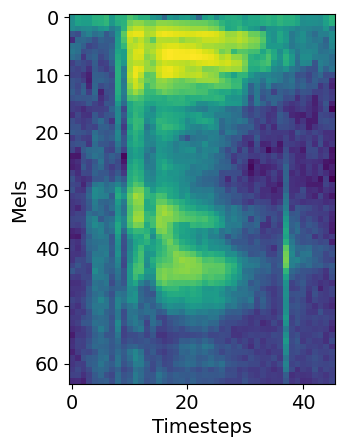

In [9]:
spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=64)
logmel_spec = spectrogram(resampled_waveform.squeeze())
print(f'Spectrogram shape: {logmel_spec.shape}')
print(f'Values range: ({logmel_spec.min(), logmel_spec.max()})')

plt.imshow(logmel_spec.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

### DataSet

In [10]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label

In [11]:
def collate(batch):
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

### Создание DataSet

In [12]:
# Ensure data loading correctly
_test_dataset = AudioMNISTDataset(root)
_test_dataset[0]

(tensor([[0.0003, 0.0005, 0.0004,  ..., 0.0005, 0.0005, 0.0006]]), 0)

### Data Split

Сплитим так, чтобы в train были не все speakers, чтобы проверить модель на обобщающую способность.

In [13]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs

In [14]:
# Split dataset by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

### Архитектура

#### Модель 1

In [15]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

In [16]:
class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, num_classes = 10):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        # self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)

        # size after avgpool = [32, 512, 1]
        self.fc = nn.Linear(in_features = 256, out_features = num_classes)

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        # x = self.layer4(x)

        x = self.avgpool(x)

        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)

        return x

    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)

def CreateResNet1D():
    return ResNet1D(block)

In [17]:
class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels, num_classes = 10):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(in_features = 512, out_features = num_classes)

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)

### Обучим Модель 1

In [18]:
model = CreateResNet1D()
model = model.to(device)

In [18]:
train_loader = DataLoader(train_ds, batch_size = 128, shuffle = True, collate_fn=collate)
test_loader = DataLoader(valid_ds, batch_size = 128, shuffle = False, collate_fn=collate)

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

#### Обучение.

In [21]:
num_epochs = 5

In [22]:
num_epochs = 5
train_losses = []
valid_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

    for wavs, labels in train_bar:
        wavs = wavs.unsqueeze(1).to(device)  # [B, 1, T]
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(wavs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Валидация
    model.eval()
    correct = 0
    total = 0

    val_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad():
        for wavs, labels in val_bar:
            wavs = wavs.unsqueeze(1).to(device)
            labels = labels.to(device)
            logits = model(wavs)
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            val_bar.set_postfix(acc=f"{correct/total:.4f}")

    accuracy = correct / total
    valid_accuracies.append(accuracy)

    # Выводим итоги эпохи
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f}, Val Accuracy: {accuracy:.4f}")
    print("-" * 50)

# Финальный вывод
print("\nTraining completed!")
print(f"Final validation accuracy: {valid_accuracies[-1]:.4f}")

Epoch 1/5 - Loss: 0.4827, Val Accuracy: 0.8548
--------------------------------------------------


Epoch 2/5 - Loss: 0.1253, Val Accuracy: 0.8757
--------------------------------------------------


Epoch 3/5 - Loss: 0.0802, Val Accuracy: 0.8912
--------------------------------------------------


Epoch 4/5 - Loss: 0.0603, Val Accuracy: 0.9200
--------------------------------------------------


Epoch 5/5 - Loss: 0.0553, Val Accuracy: 0.9082
--------------------------------------------------

Training completed!
Final validation accuracy: 0.9082


### Результаты и выводы.

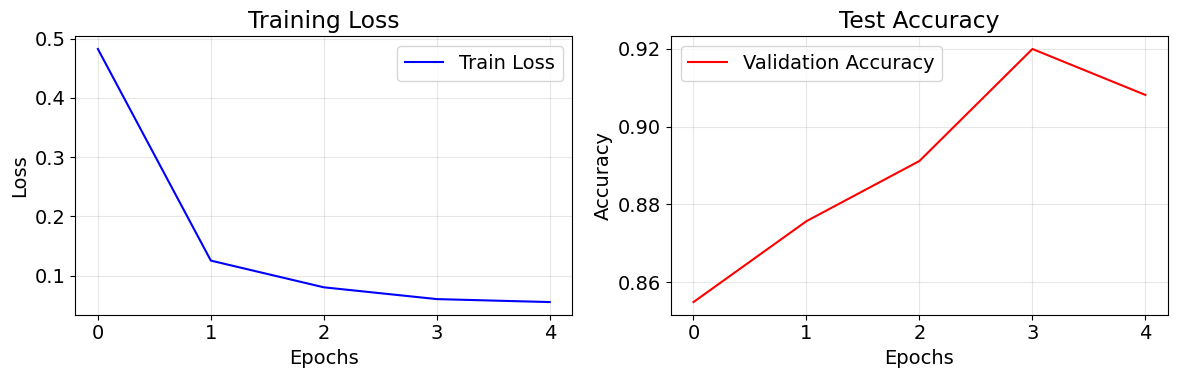

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, 'b-', label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), valid_accuracies, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
model.eval()
sample_idx = 0
wav, label = valid_ds[sample_idx]
wav = wav.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(wav)
    predicted = torch.argmax(logits, dim=1)

print(f"True label: {label}")
print(f"Predicted label: {predicted.item()}")

original_idx = valid_ds.indices[sample_idx]
sample_path = full_ds.items[original_idx][0]

Audio(sample_path, rate=16000)

True label: 0
Predicted label: 0


**Вывод**:

Качество нашего классификатора получилось очень хорошее, при чем модель умеет хорошо обобщать результаты на других спикеров. Минус модели, что она очень долго обучается, но это минус всех сложных и больших архитектур.

Таким образом мы построили сверточную нейронную сеть для классификации аудио. Получили accuracy = 93% На validation датасете.

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

#### Модель 1

In [22]:
class block_1d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block_1d, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

In [67]:
class ResNet1D_task_2(nn.Module):
    def __init__(self, block, num_channels=1):
        super(ResNet1D_task_2, self).__init__()
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(num_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, layers[0], 32, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 32, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 32, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)

        return x

    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * self.expansion:
            identity_downsample = nn.Sequential(
                nn.Conv1d(self.in_channels,
                          out_channels * self.expansion,
                          kernel_size=1,
                          stride=stride,
                          bias=False),
                nn.BatchNorm1d(out_channels * self.expansion),
            )
        layers.append(
            block(self.in_channels, out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


def CreateResNet1D_task_2(num_channels=1):
    return ResNet1D_task_2(block_1d, num_channels=num_channels)

#### Модель 2

In [24]:
class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

In [25]:
class ResNet2D_task_2(nn.Module):
    def __init__(self, block, image_channels):
        super(ResNet2D_task_2, self).__init__()
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)

        return x

    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * self.expansion:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels,
                          out_channels * self.expansion,
                          kernel_size=1,
                          stride=stride,
                          bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )
        layers.append(
            block(self.in_channels, out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


def CreateResNet2D_task_2(img_channels=1):
    return ResNet2D_task_2(block_resnet2d, image_channels=img_channels)

#### Итоговая Архитектура.

In [26]:
class Net(nn.Module):
    def __init__(self, img_channels=1, num_classes=10):
        super(Net, self).__init__()

        self.resnet_1D = CreateResNet1D_task_2(num_channels=1)
        self.resnet_2D = CreateResNet2D_task_2(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

    def forward(self, input_spectogram, input_audio):
        audio = self.resnet_1D(input_audio)
        audio = audio.squeeze()

        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze()

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms

In [27]:
class EvaluationHead(nn.Module):
    def __init__(self, input_dim=256, num_classes=10):
        super(EvaluationHead, self).__init__()
        self.evaluation = nn.Sequential(
            nn.Linear(input_dim, num_classes)
        )

    def forward(self, x):
        x = self.evaluation(x)
        return x

#### Contrastive loss (seminar)

In [48]:
def device_as(t1, t2):
   return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss

#### Augmentaitions

In [28]:
def pitchshift(audio, SAMPLE_RATE=16000, shift = 2):
    """
    Pitch Shift (PS): randomly raises or lowers the pitch of the audio signal.\n
    Based on experimental observation,we found the range of pitch shifts that main-tained\n
    the overall coherency of the input audio was in the range [-15, 15] semitones.

    Attributes:
    - :param audio: audio tensor
    - :param SAMPLE_RATE: Sample rate, default=16000
    - :param shift: Pitch shift
    - :return: describe what it returns
    """
    assert audio != None, "audio should not be None"
    transform = transforms.PitchShift(sample_rate=SAMPLE_RATE, n_steps=shift)
    waveform_shift = transform(audio)
    return waveform_shift


def fade_in_out(audio):
    """
    Fade in/out (FD): gradually increases/decreases the intensity of the audio in the\n
    beginning/end of the audio signal.\n
    The degree of the fade was either linear, logarithmic or exponential (applied\n
    with uniform probability of 1/3). The size of the fade for either side of the\n
    audio signal could at maximum reach half of the audio signal. The size of the\n
    fade was another random parameter picked for each sample.
    """
    assert audio != None, "audio should not be None"
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    _fade_size = [i for i in range(1, int(audio.shape[2]/2))]

    transform = transforms.Fade(fade_in_len=random.choice(_fade_size), fade_out_len=random.choice(_fade_size), fade_shape=random.choice(_fade_shape))
    waveform_fade_in_out = transform(audio)
    return waveform_fade_in_out

def add_white_noise_(signal, noise_level):
    """
    Noise Injection: mix the audio signal with random white, brown and pink noise.\n
    In our implementation, the intensity of the noise signal was randomly selected based\n
    on the strength of signal-to-noise ratio. Applied white, brown, or pink depending\n
    on an additional random parameter sampled from uniform distribution (Mixed Noise).
    """
    noise = torch.randn_like(signal)*torch.std(signal) * noise_level
    noisy_signal = signal + noise
    return noisy_signal


def timemasking(waveform, batch_size, sample_rate=16000):
    """
    Time masking:given an audio signal, in this transformation we randomly select a small\n
    segment of the full signal and set the signal values in that segment to normal noise or a\n
    constant value. In our implementation, we not only randomly selected the location of the\n
    masked segment but also we randomly selected the size of the segment. The size of the \n
    masked segment was set to maximally be 1/8 of the input signal.
    """
    """max_mask = int(sample_rate/8)*torch.ones(size=[batch_size])
    pos_iniziale = torch.randint(low=0, high=sample_rate, size=[batch_size])
    min_mask = sample_rate-pos_iniziale
    min_elements = torch.min(min_mask,max_mask)
    pos_finale = pos_iniziale+min_elements.to(torch.int)
    indices = torch.arange(sample_rate).unsqueeze(0).expand(batch_size, -1)
    range_mask = (indices >= pos_iniziale.unsqueeze(1)) & (indices <= pos_finale.unsqueeze(1))
    range_mask = range_mask[:,None,:]
    signal_[range_mask] = 0

    return signal_"""
    bs, ch, length = waveform.shape
    mask_len = length // 8
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented

#### Training

In [46]:
def create(config):
    # Create model
    model = Net(img_channels=config.IMG_CHANNEL, num_classes=config.CLASSES).to(device)

    # Define the constrastive loss
    loss = ContrastiveLoss()

    # Define Melspectogram
    mel_transform = LogMelSpectrogram(
        sample_rate=16000,
        n_fft=2048,
        hop_length=128,
        n_mels=128,
        f_min=40,
        f_max=8000,
        mel_scale="slaney"
    )

    mel_transform = mel_transform.to(device)

    # Define the optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=config.LR,
        betas=(config.B1, config.B2),
        weight_decay=config.WEIGHT_DECAY
    )

    return model, loss, optimizer, mel_transform

In [41]:
def createModelInput(audio, mel_transform, stft_transform, augmentation=True):
    audio = audio.unsqueeze(1)

    if augmentation:
        audio = fade_in_out(audio)
        audio = timemasking(audio, audio.shape[0])

    if hasattr(mel_transform, 'window') and mel_transform.window is not None:
        mel_transform.window = mel_transform.window.to(audio.device)

    mel_transform = mel_transform.to(audio.device)

    spectograms = mel_transform(audio)

    return spectograms, audio

In [29]:
def train_evaluation_head(model, train_loader, mel_transform, device,
                          num_epochs=10, lr=0.001, input_dim=256, num_classes=10):

    eval_head = EvaluationHead(input_dim=input_dim, num_classes=num_classes).to(device)

    optimizer = optim.Adam(eval_head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    head_losses = []

    model.eval()

    eval_head.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0

        with tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False) as pbar:
            for audio, labels in pbar:
                audio = audio.to(device)

                spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=False)

                with torch.no_grad():
                    audio_emb, spect_emb, frozen_audio, frozen_spects = model(spectograms, audios)

                    if len(frozen_audio.shape) > 2:
                        frozen_audio = frozen_audio.squeeze()
                    if len(frozen_spects.shape) > 2:
                        frozen_spects = frozen_spects.squeeze()

                inputs = torch.cat([frozen_audio, frozen_spects], dim=0)

                labels_cat = torch.cat([labels, labels], dim=0).to(device)

                outputs = eval_head(inputs)
                loss = criterion(outputs, labels_cat)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                _, predicted = torch.max(outputs.data, 1)
                total += labels_cat.size(0)
                correct += (predicted == labels_cat).sum().item()
                epoch_loss += loss.item()

                pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

        avg_loss = epoch_loss / len(train_loader)
        head_losses.append(avg_loss)
        print(f"  Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {correct/total:.4f}")

    return eval_head, head_losses

In [30]:
def evaluate_accuracy(model, eval_head, val_loader, mel_transform, device):

    eval_head.eval()
    correct = 0
    total = 0

    with tqdm(val_loader, desc="Evaluating", leave=False) as pbar:
        with torch.no_grad():
            for audio, labels in pbar:
                audio = audio.to(device)
                spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=False)
                labels_cat = torch.cat([labels, labels], dim=0).to(device)

                _, _, frozen_audio, frozen_spects = model(spectograms, audios)
                inputs = torch.cat([frozen_audio, frozen_spects], dim=0)
                outputs = eval_head(inputs)
                _, predicted = torch.max(outputs.data, 1)

                total += labels_cat.size(0)
                correct += (predicted == labels_cat).sum().item()
                pbar.set_postfix(acc=f"{correct/total:.4f}")

    return correct / total

def validate_model(model, val_loader, mel_transform, device):

    print("  Training evaluation head...")
    eval_head, head_losses = train_evaluation_head(model, train_loader, mel_transform, device)

    print("  Computing accuracy...")
    accuracy = evaluate_accuracy(model, eval_head, val_loader, mel_transform, device)

    return accuracy, head_losses

#### Инициализация

In [31]:
class Config:
    def __init__(self):
        self.EPOCHS = 5
        self.EVAL_EPOCHS = 5
        self.LR = 1e-3
        self.B1 = 0.9
        self.B2 = 0.999
        self.WEIGHT_DECAY = 1e-4
        self.IMG_CHANNEL = 1
        self.CLASSES = 10
        self.MODEL_TITLE = "contrastive_audio"
        self.BATCH_SIZE = 128
        self.TEMPERATURE = 0.5
        self.EVAL_EVERY = 3

config = Config()

In [49]:
model, closs, optimizer, mel_transform = create(config)

# Для хранения метрик
train_losses = []
val_accuracies = []

# Для ранней остановки
best_accuracy = 0
patience_counter = 0
early_stop_patience = 5

In [34]:
for epoch in range(config.EPOCHS):
    model.train()
    epoch_loss = 0.0

    # Обучение
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS}", leave=False)
    for audio, labels in train_bar:
        optimizer.zero_grad()
        audio = audio.to(device)

        spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)
        audio_emb, spect_emb, _, _ = model(spectograms, audios)
        loss = closs(audio_emb, spect_emb)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Валидация каждые 3 эпохи
    if (epoch + 1) % 3 == 0:
        print(f"\n--- Validation at epoch {epoch+1} ---")
        accuracy, _ = validate_model(model, test_loader, mel_transform, device)
        val_accuracies.append(accuracy)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            patience_counter = 0
            print(f"Accuracy: {accuracy:.4f}")
        else:
            patience_counter += 1
            print(f"Accuracy: {accuracy:.4f} (best: {best_accuracy:.4f})")

        if patience_counter >= early_stop_patience:
            print(f"Early stopping after {epoch+1} epochs")
            break
    else:
        print(f"Epoch {epoch+1} completed. Loss: {avg_loss:.4f}")

Epoch 1 completed. Loss: 9.5485


Epoch 2 completed. Loss: 9.3009



--- Validation at epoch 3 ---
  Training evaluation head...


  Epoch 1: Loss = 1.9523, Accuracy = 0.3289


  Epoch 2: Loss = 1.6778, Accuracy = 0.4417


...

  Epoch 9: Loss = 1.2767, Accuracy = 0.6173


  Epoch 10: Loss = 1.2492, Accuracy = 0.6279
  Computing accuracy...


Accuracy: 0.5533


Epoch 4 completed. Loss: 9.2625


Epoch 5 completed. Loss: 9.2337


In [36]:
eval_head, head_losses = train_evaluation_head(model, train_loader, mel_transform, device, num_epochs=3)

  Epoch 1: Loss = 1.9163, Accuracy = 0.3589


  Epoch 2: Loss = 1.5988, Accuracy = 0.4999


  Epoch 3: Loss = 1.4583, Accuracy = 0.5536


NameError: name 'val_loader' is not defined

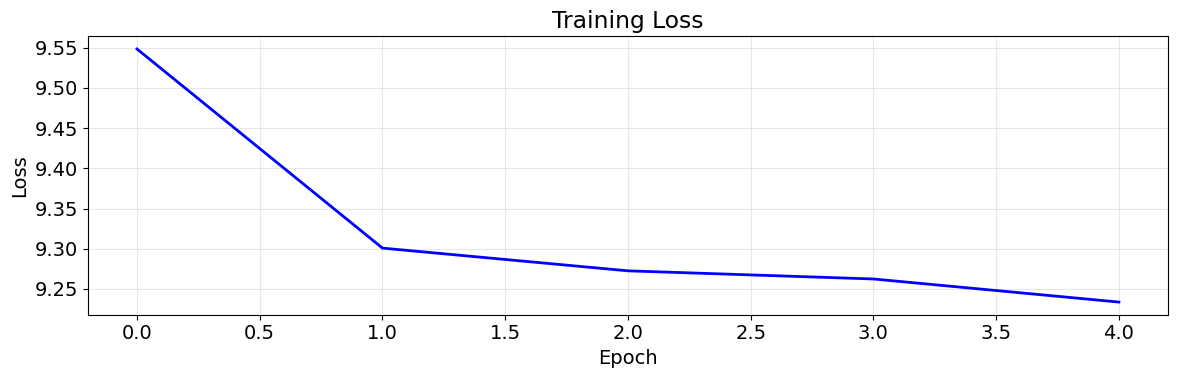

In [38]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 4))

# Loss
ax1.plot(train_losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод**:

Можно сделать выводы, что SSL метод обучения во много раз сложнее и дольше в сходимости, чем обычные методы. В качестве такой метод тоже уступает, однако мы обучались на данных без разметки и получили более качественное представление данных в латентном пространстве. А именно мы пытались максимизировать расстояние между разными представлениями цифр.

На таком маленьком и простом датасете SSL метод не является самым уневирсальным. Но в качестве первого знакомства является отличным примером.

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


### Давайте реализуем Модель BYOL

Модель состоит из 2-х сетей, одна называется online, Другая target.

online = encoder -> project->predictor->output

target = encoder -> project-> output

потом считается общий лосс между двумя выходами на основе их близости.

In [68]:
class BYOL(nn.Module):
    def __init__(self, encoder, projection_dim=256, hidden_dim=4096, tau=0.996):
        super().__init__()

        self.online_encoder = encoder
        self.online_projector = nn.Sequential(
            nn.Linear(projection_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )
        self.online_predictor = nn.Sequential(
            nn.Linear(projection_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, projection_dim)
        )

        self.target_encoder = copy.deepcopy(encoder)
        self.target_projector = copy.deepcopy(self.online_projector)

        for param in self.target_encoder.parameters():
            param.requires_grad = False
        for param in self.target_projector.parameters():
            param.requires_grad = False

        self.tau = tau

    def forward(self, x1, x2):
        #Обучаем онлайн сеть
        online_feat = self.online_encoder(x1)
        online_proj = self.online_projector(online_feat)
        online_pred = self.online_predictor(online_proj)

        #Заморозил таргет сеть, чтобы не училась
        with torch.no_grad():
            target_feat = self.target_encoder(x2)
            target_proj = self.target_projector(target_feat)

        online_pred = F.normalize(online_pred, dim=1)
        target_proj = F.normalize(target_proj, dim=1)

        loss = 2 - 2 * (online_pred * target_proj).sum(dim=1).mean()

        return loss

    @torch.no_grad()
    def update_target_network(self):
        for target_param, online_param in zip(
            self.target_encoder.parameters(),
            self.online_encoder.parameters()
        ):
            target_param.data = self.tau * target_param.data + (1 - self.tau) * online_param.data

        for target_param, online_param in zip(
            self.target_projector.parameters(),
            self.online_projector.parameters()
        ):
            target_param.data = self.tau * target_param.data + (1 - self.tau) * online_param.data

    def get_representation(self, x):
        return self.online_encoder(x)

In [69]:
def train_byol(model, train_loader, mel_transform, device, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for audio, _ in progress_bar:
            audio = audio.to(device)

            spec1, audio1 = createModelInput(audio, mel_transform, None, augmentation=True)
            spec2, audio2 = createModelInput(audio, mel_transform, None, augmentation=True)

            audio1 = audio1.squeeze(1)  # [B, T]
            audio2 = audio2.squeeze(1)  # [B, T]
            loss = model(audio1, audio2)

            # loss = model(spec1, spec2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            model.update_target_network()

            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

        if (epoch + 1) % 10 == 0:
            accuracy, _ = validate_model(model, test_loader, mel_transform, device)
            print(f"  Validation accuracy: {accuracy:.4f}")

    return losses

In [70]:
# Создаем энкодеры
audio_encoder = CreateResNet1D_task_2(num_channels=1).to(device)
# spec_encoder = CreateResNet2D_task_2(img_channels=1).to(device)

In [71]:
byol_audio = BYOL(
    encoder=audio_encoder,
    projection_dim=32,
    hidden_dim=256,
    tau=0.996
).to(device)

# byol_spec = BYOL(
#     encoder=spec_encoder,
#     projection_dim=256,
#     hidden_dim=4096,
#     tau=0.996
# ).to(device)

In [72]:
def train_byol_with_evaluation(byol_model, train_loader, val_loader, mel_transform, device,
                                byol_epochs=100, head_epochs=30):

    optimizer_byol = torch.optim.Adam(byol_model.parameters(), lr=1e-3)
    byol_losses = []

    for epoch in range(byol_epochs):
        byol_model.train()
        epoch_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"BYOL Epoch {epoch+1}/{byol_epochs}")

        for audio, _ in progress_bar:
            audio = audio.to(device)

            _, audio1 = createModelInput(audio, mel_transform, None, augmentation=True)
            _, audio2 = createModelInput(audio, mel_transform, None, augmentation=True)

            loss = byol_model(audio1, audio2)

            optimizer_byol.zero_grad()
            loss.backward()
            optimizer_byol.step()

            byol_model.update_target_network()

            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        byol_losses.append(avg_loss)
        print(f"BYOL Epoch {epoch+1}/{byol_epochs}, Loss: {avg_loss:.4f}")

    # Заморозка энкодера
    for param in byol_model.online_encoder.parameters():
        param.requires_grad = False
        
    classifier_head = nn.Sequential(
        nn.Linear(32, 16),
        nn.BatchNorm1d(16),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(16, 10),
        nn.BatchNorm1d(10),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(10, 10)
    ).to(device)

    optimizer_head = torch.optim.Adam(classifier_head.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    head_losses = []
    head_accuracies = []
    best_accuracy = 0.0

    for epoch in range(head_epochs):
        classifier_head.train()
        epoch_loss = 0.0
        correct_train = 0
        total_train = 0

        train_bar = tqdm(train_loader, desc=f"Head Epoch {epoch+1}/{head_epochs} [Train]", leave=False)

        for audio, labels in train_bar:
            audio = audio.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                _, aud = createModelInput(audio, mel_transform, None, augmentation=False)
                embedding = byol_model.get_representation(aud)  # [B, 256]

            output = classifier_head(embedding)
            loss = criterion(output, labels)

            optimizer_head.zero_grad()
            loss.backward()
            optimizer_head.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(output, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct_train/total_train:.4f}")

        classifier_head.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0

        val_bar = tqdm(val_loader, desc=f"Head Epoch {epoch+1}/{head_epochs} [Val]", leave=False)

        with torch.no_grad():
            for audio, labels in val_bar:
                audio = audio.to(device)
                labels = labels.to(device)

                _, aud = createModelInput(audio, mel_transform, None, augmentation=False)
                embedding = byol_model.get_representation(aud)
                output = classifier_head(embedding)

                loss = criterion(output, labels)
                val_loss += loss.item()

                _, predicted = torch.max(output, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

                val_bar.set_postfix(acc=f"{correct_val/total_val:.4f}")

        val_accuracy = correct_val / total_val
        avg_val_loss = val_loss / len(val_loader)

        head_losses.append(avg_val_loss)
        head_accuracies.append(val_accuracy)

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy

        print(f"  Epoch {epoch+1}: Val Loss = {avg_val_loss:.4f}, Val Acc = {val_accuracy:.4f}")

    return byol_losses, head_losses, head_accuracies, best_accuracy

In [ ]:
byol_losses, head_losses, head_accuracies, best_accuracy = train_byol_with_evaluation(
    byol_model=byol_audio,
    train_loader=train_loader,
    val_loader=test_loader,
    mel_transform=mel_transform,
    device=device,
    byol_epochs=6,
    head_epochs=7
)

BYOL Epoch 1/6: 100%|██████████| 188/188 [03:42<00:00,  1.18s/it, loss=0.1991]


BYOL Epoch 1/6, Loss: 0.2580


BYOL Epoch 2/6: 100%|██████████| 188/188 [03:42<00:00,  1.18s/it, loss=0.1959]


BYOL Epoch 2/6, Loss: 0.1941


BYOL Epoch 3/6: 100%|██████████| 188/188 [03:43<00:00,  1.19s/it, loss=0.1472]


...

  Epoch 1: Val Loss = 1.9719, Val Acc = 0.2858


  Epoch 2: Val Loss = 2.0528, Val Acc = 0.2952


  Epoch 3: Val Loss = 2.2057, Val Acc = 0.3077


  Epoch 4: Val Loss = 2.4419, Val Acc = 0.2895


Head Epoch 5/7 [Train]:  27%|██▋       | 51/188 [00:55<02:28,  1.08s/it, acc=0.5784, loss=1.0557]

**Выводы**

Можно увидеть, что модель модель не смогла сойтись, так как у меня нет достаточных вычислительных ресурсов я не могу сказать, сколько именно нужно модели для того, чтобы сойтись. Поэтому данный метод является очень трудоемким и дорогостоящим.

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

В этом ноутбуке я попрактиковался с разными способами классификации звука, такими как SSL, обычная классификация и  NCL. Лучше всего себя показали базовый метод обучения с учителем: 92% на валидационных данных. Хуже всего NLC, так как этот метод требует очень много вычислительных ресурсов к которым не имею доступа. SSL показал неплохие результаты, но тоже является очень дорогостоящим алгоритмом. 

Преимущества SSL и NLC в том, что они не просто запоминают данные, а формируют внутренние представления и в случае чего, их легко дообучить, что мы и делали (создавали голову классификации). Обучение с учителем же, оказалось очень быстрым и простым, а также дало наибольший прирост качества, но не дало интерпретируемости результатов, а также вариативности.

Могу дополнить, что самое стабильное обучение было у первых двух методов, в то время как, у BYOL возникли определенные проблемы с обучением, такие как застревание в константном предсказании.  

PS, не хватило вычислительных мощностей (2 раза упал колаб и 1 раз упал kaggle), надеюсь что все сделал хорошо, вплане архитектуры, ибо очень много времени потратил на прочтение и изучение доп материалов. Заранее спасибо за ревью